FileNotFoundError: [Errno 2] No such file or directory: '/mnt/年龄_并发症率.png'

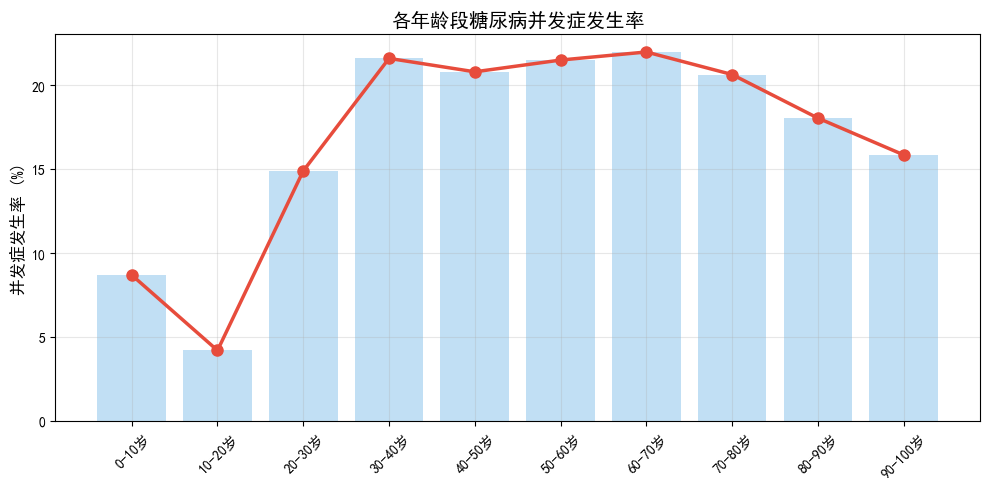

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_excel('diabetic_data.xlsx')

# --------------------- 2.1.1 年龄 vs 并发症率 ---------------------
age_labels = {
    1: '0-10岁', 2: '10-20岁', 3: '20-30岁',
    4: '30-40岁', 5: '40-50岁', 6: '50-60岁',
    7: '60-70岁', 8: '70-80岁', 9: '80-90岁', 10: '90-100岁'
}

# 计算每个年龄的并发症率
age_comp = df.groupby('年龄')['has_complication'].mean() * 100
age_count = df.groupby('年龄').size()

# 绘图
plt.figure(figsize=(10, 5))
x = [age_labels[i] for i in age_comp.index]
y = age_comp.values
plt.plot(x, y, marker='o', linewidth=2.5, markersize=8, color='#E74C3C')
plt.bar(x, y, alpha=0.3, color='#3498DB')
plt.title('各年龄段糖尿病并发症发生率', fontsize=14)
plt.ylabel('并发症发生率 (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/年龄_并发症率.png', dpi=300)
plt.close()

# 输出结果
print("=== 各年龄段并发症发生率（%）===")
for age, rate in age_comp.items():
    print(f"{age_labels[age]}: {rate:.1f}%")